In [57]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')







In [58]:
df=pd.read_csv('heart.csv')
df.head()



,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA

In [59]:
df.info()

df.columns

df.describe()

df.isnull().sum()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [60]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [61]:
df.shape

(918, 12)

In [62]:
df.duplicated().sum()




np.int64(0)

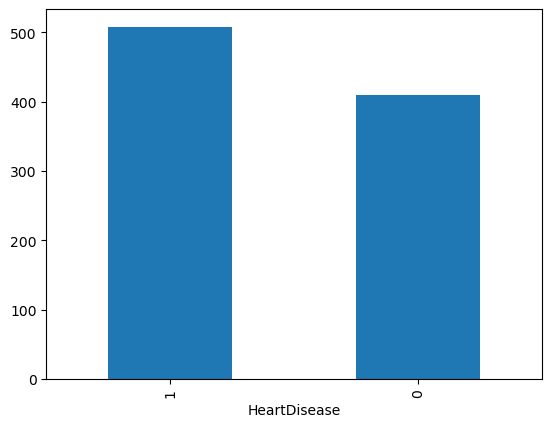

In [63]:
df['HeartDisease'].value_counts().plot(kind='bar')
plt.show()






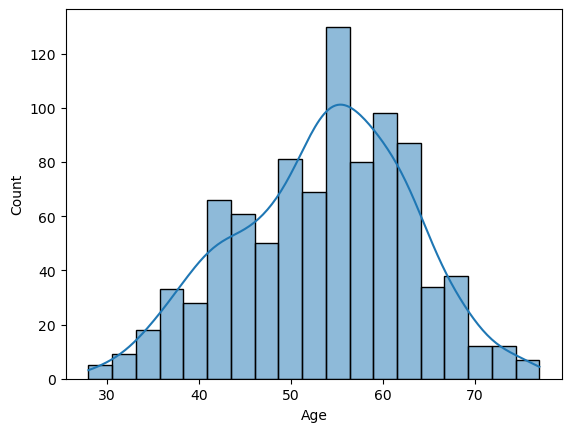

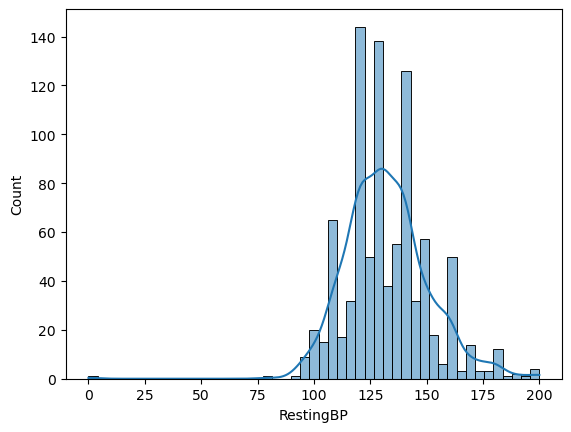

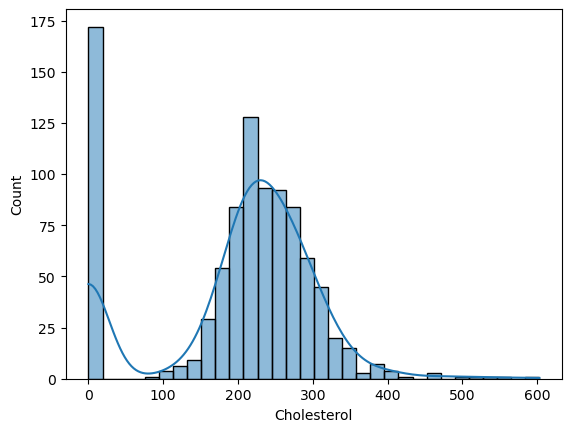

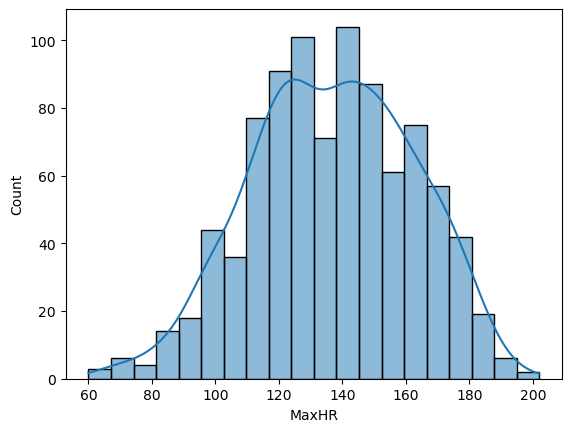

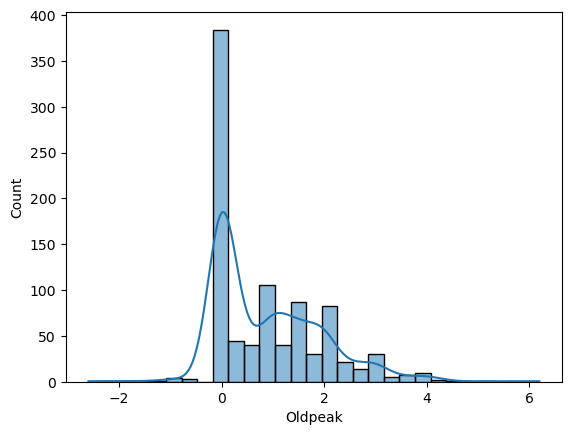

In [64]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
for col in cols:
    sns.histplot(df[col], kde=True)
    plt.show()



In [65]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [66]:
# keep only non-zero cholesterol rows
chol_non_zero = df[df['Cholesterol'] != 0]['Cholesterol']

# show all non-zero values
print(chol_non_zero)

# mean of only non-zero values
print("Mean (non-zero Cholesterol):", chol_non_zero.mean())

0      289
1      180
2      283
3      214
4      195
      ... 
913    264
914    193
915    131
916    236
917    175
Name: Cholesterol, Length: 746, dtype: int64
Mean (non-zero Cholesterol): 244.6353887399464


In [67]:
df['Cholesterol']=df['Cholesterol'].replace(0,chol_non_zero.mean())

<Axes: xlabel='Cholesterol', ylabel='Count'>

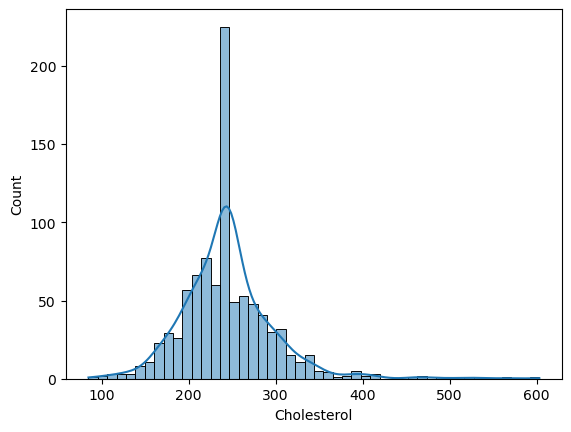

In [68]:
sns.histplot(df['Cholesterol'],kde=True)

In [69]:
df['Cholesterol']=df['Cholesterol'].round(2)

<Axes: xlabel='RestingBP', ylabel='Count'>

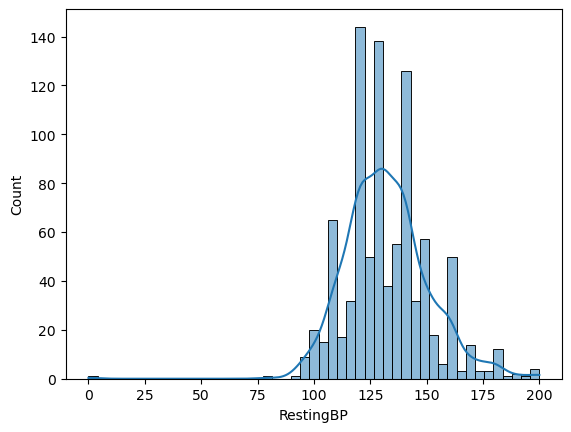

In [70]:
sns.histplot(df['RestingBP'],kde=True)

In [71]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
185      1
98       1
92       1
113      1
164      1
Name: count, Length: 67, dtype: int64

In [72]:
resting_bp_non_zero=df[df['RestingBP']!=0]['RestingBP']
resting_bp_non_zero.mean()
df['RestingBP']=df['RestingBP'].replace(0,resting_bp_non_zero.mean())

<Axes: xlabel='RestingBP', ylabel='Count'>

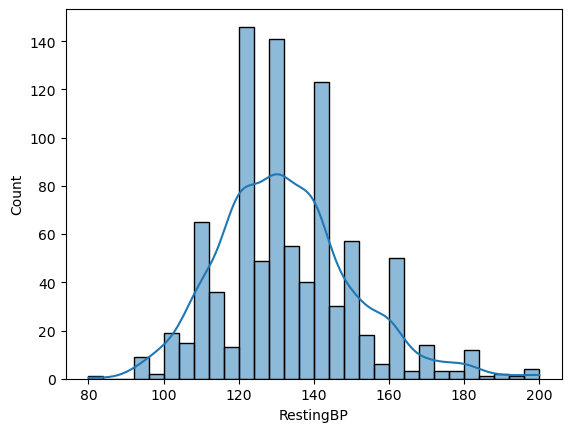

In [73]:
sns.histplot(df['RestingBP'],kde=True)

In [74]:
pip install sheryanalysis==0.1.0

Note: you may need to restart the kernel to use updated packages.


In [75]:
import sheryanalysis as sh
sh.analyze(df)




🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': dtype('O'),
  'ChestPainType': dtype('O'),
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': dtype('O'),
  'MaxHR': dtype('int64'),
  'ExerciseAngina': dtype('O'),
  'Oldpeak': dtype('float64'),
  'ST_Slope': dtype('O'),
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',
   'ExerciseAngina',
   'ST_Slope',
   'HeartDisease'],
  'numerical': ['Age', 'Rest

<Axes: xlabel='HeartDisease', ylabel='count'>

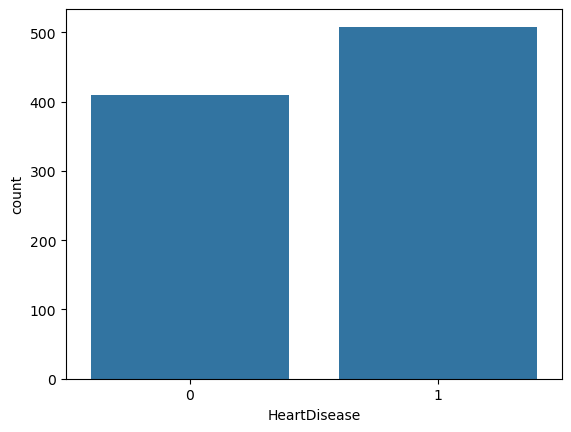

In [76]:
sns.countplot(x='HeartDisease',data=df)

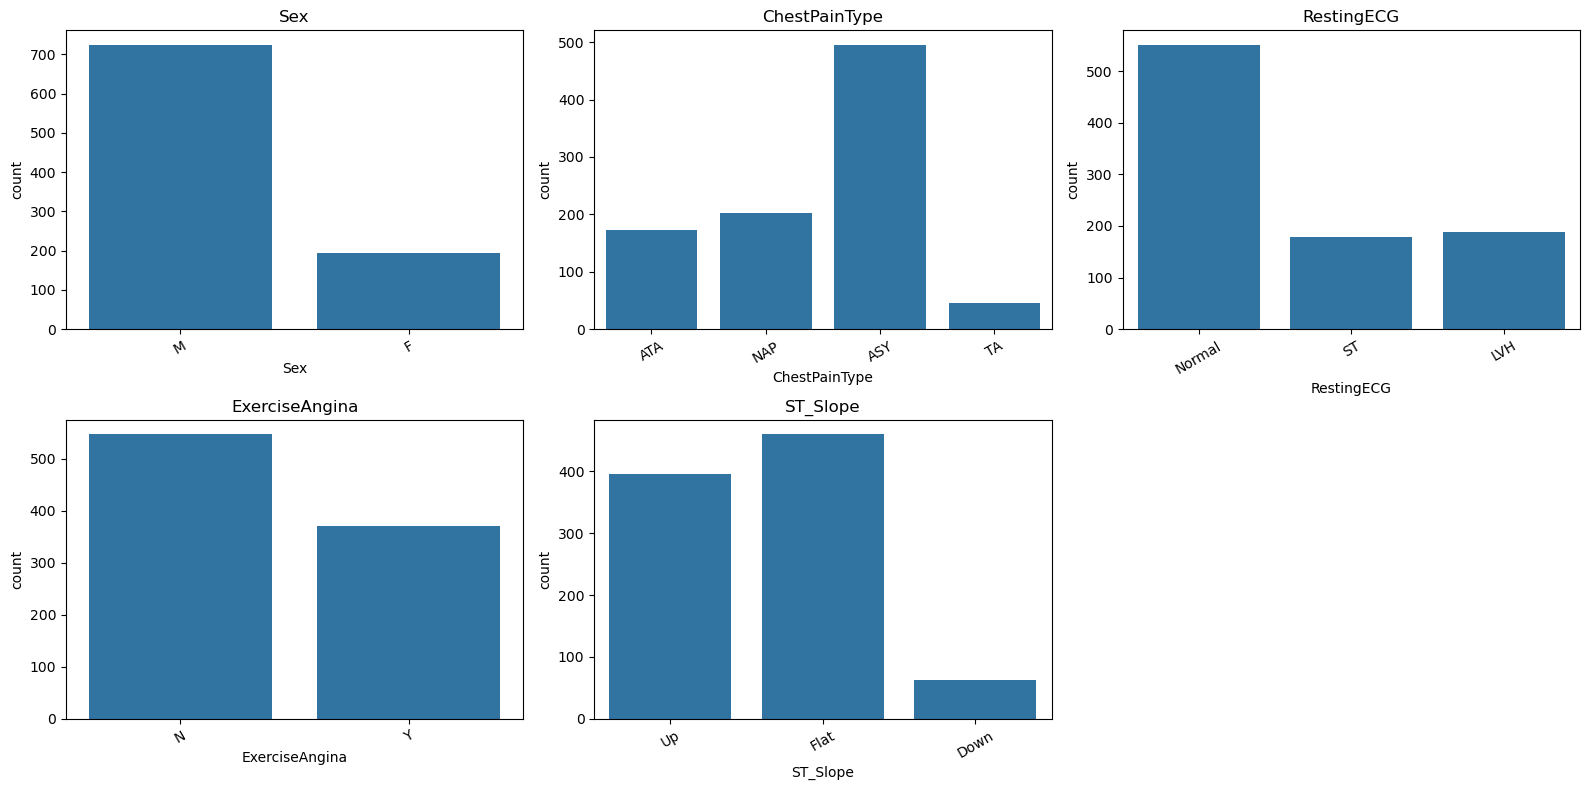

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

# Hide the extra subplot (6th axis)
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


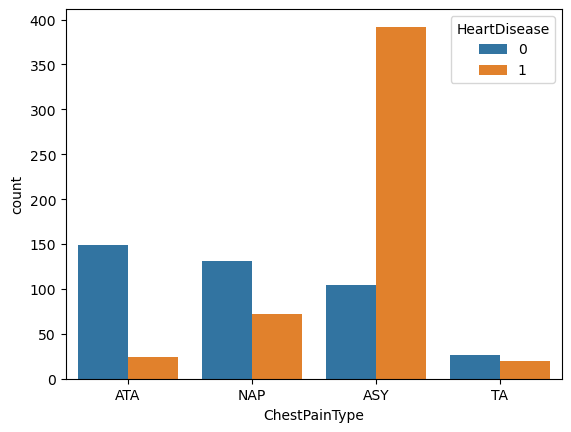

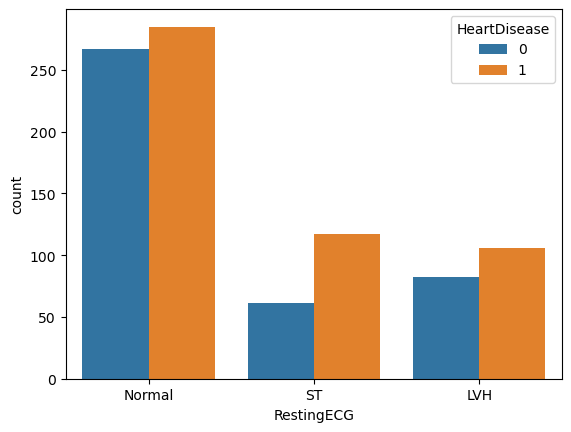

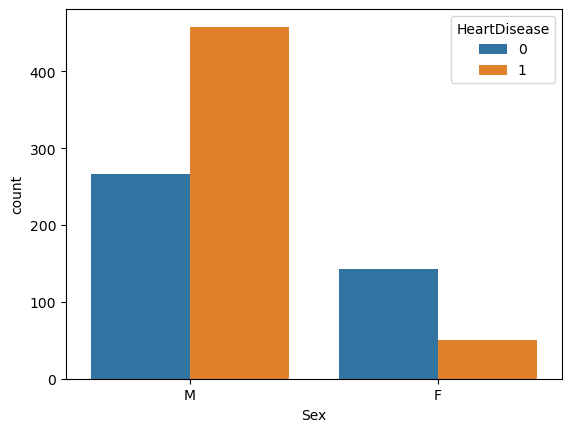

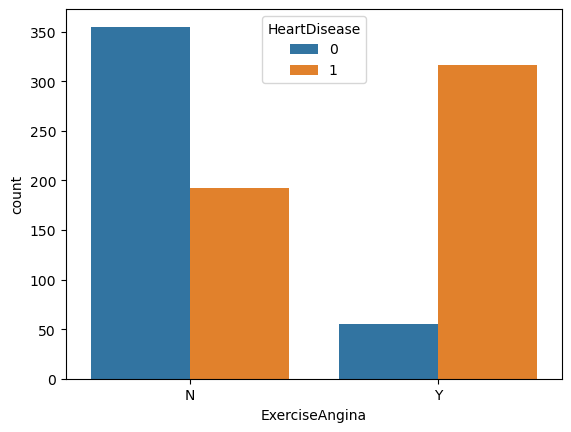

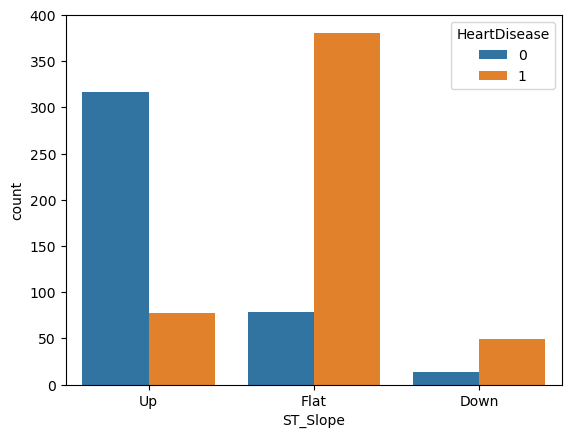

In [78]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])
plt.show()

sns.countplot(x=df['RestingECG'],hue=df['HeartDisease'])
plt.show()
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])
plt.show()
sns.countplot(x=df['ExerciseAngina'],hue=df['HeartDisease'])
plt.show()
sns.countplot(x=df['ST_Slope'],hue=df['HeartDisease'])
plt.show()





<Axes: >

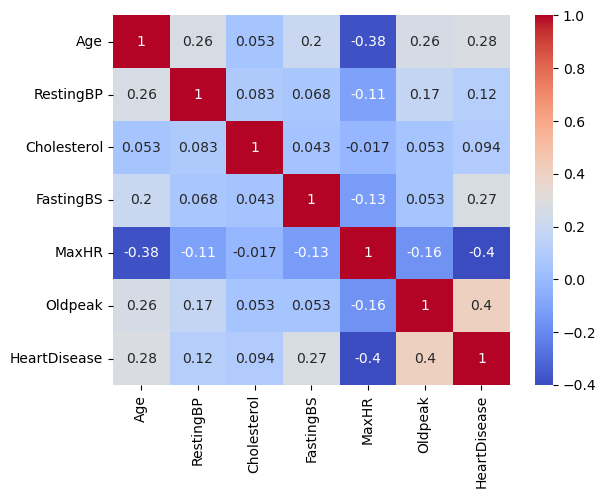

In [79]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [80]:
df_clean=pd.get_dummies(df,drop_first=True)
df_clean.head()






,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [81]:
df_clean=df_clean.astype(int)


In [82]:
df_clean.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [83]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_clean[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']]=scaler.fit_transform(df_clean[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']])
df_clean.head()




,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [84]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import f1_score








In [85]:
X=df_clean.drop('HeartDisease',axis=1)
y=df_clean['HeartDisease']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)





In [86]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)





In [87]:
models = {
    'LR': LogisticRegression(),
    'SVM': SVC(),
    'DT': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
}



In [88]:
results=[]


In [89]:
for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': accuracy, 'F1 Score': f1})



In [90]:
results

[{'Model': 'LR',
  'Accuracy': 0.8695652173913043,
  'F1 Score': 0.8846153846153846},
 {'Model': 'SVM',
  'Accuracy': 0.8478260869565217,
  'F1 Score': 0.8666666666666667},
 {'Model': 'DT',
  'Accuracy': 0.7989130434782609,
  'F1 Score': 0.8195121951219512},
 {'Model': 'KNN',
  'Accuracy': 0.8641304347826086,
  'F1 Score': 0.8815165876777251}]

In [93]:
import joblib
joblib.dump(models['KNN'],'model_knn.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns,'columns.pkl')





['columns.pkl']